# Section 3. LangChain Chains

In LangChain, the concept of Chains refers to a sequence of connected steps that together form a more complex process. Each step can involve a different task, such as asking a question to a language model, retrieving information from a database, interpreting the result, and even sending an automated response. These steps work in a chain, where the output of one serves as the input for the next—much like an assembly line.

The main idea behind Chains is to enable the system to solve tasks that are more complex than a simple question-and-answer. For example, if we want to answer a question based on an article from the internet, we first need to retrieve that article, then extract the relevant content, pass that content to the language model, and only then generate the final answer.

**In current versions of LangChain, the preferred way to build these flows is with the Runnable interface (`prompt | model | parser`).** **In this notebook, we will keep the classic chain classes only when they help explain older materials or make the comparison clearer.**

In [1]:
!pip install -qU python-dotenv langchain langchain-classic langchain-openai langchain-google-genai langchain-openrouter openrouter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 17.8 MB/s eta 0:00:00


In [2]:
import getpass
import os

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_openrouter import ChatOpenRouter

def get_model_name(model_name, temperature=0):
    if model_name == "gemini": # https://ai.google.dev/gemini-api/docs/rate-limits?hl=pt-br
        if "GOOGLE_API_KEY" not in os.environ: # https://ai.google.dev/gemini-api/docs/api-key
            os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")
        llm = ChatGoogleGenerativeAI(
            # model="gemini-1.5-pro", # max 50 / dia
            model="gemini-1.5-flash", # max 1500 / dia
            temperature=temperature,
        )
    elif model_name == "openai":
        if "OPENAI_API_KEY" not in os.environ: # https://platform.openai.com
            os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")
        llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=temperature,
        )
    elif model_name == "openrouter": # https://openrouter.ai/workspaces/default/
        if not os.getenv("OPENROUTER_API_KEY"):
            os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API key: ")

        llm = ChatOpenRouter(
            model="openrouter/free",
            api_key=os.environ["OPENROUTER_API_KEY"],
            temperature=temperature,
        )

    return llm

llm = get_model_name('openrouter')

In this notebook, we’ll use a small data source available in the files for this module, so upload the `Data.csv` file to Google Colab and then run the line below.

In [5]:
import pandas as pd
df = pd.read_csv('Data.csv')
df.head()

,Product,Review
0,Queen Size Sheet Set,I ordered a king size set. My only criticism w...
1,Waterproof Phone Pouch,"I loved the waterproof sac, although the openi..."
2,Luxury Air Mattress,This mattress had a small hole in the top of i...
3,Pillows Insert,This is the best throw pillow fillers on Amazo...
4,Milk Frother Handheld\n,I loved this product. But they only seem to l...


## 3.1 LLMChain

As we saw in the previous class, the simplest way to create a Chain in LangChain is by using the `|` syntax (known as the Runnable style), following the structure `prompt | llm`. Another way would be using `LLMChain`, but this method is deprecated in favor of Runnable.

In the following cell, we define our `StructuredOutput`. In this case, we want to receive only one company name that produces the given product. If we’re not specific about this, language models (LLMs) tend to return multiple options, which can break the rest of the Chain we’ll build next.

In [10]:
from langchain_classic.chains import LLMChain
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import StrOutputParser

class StructuredOutput(BaseModel):
    company: str = Field(description='Company name')

# Step 2: Prompt Template
prompt = ChatPromptTemplate.from_template(
    "What is a very creative name for a company that makes {product}? Be creative and return a single name."
)

llm2 = llm.with_structured_output(StructuredOutput)

# Define the Chain using | syntax (Runnable style)
chain1 = prompt | llm2

product = "Queen Size Sheet Set"
result = chain1.invoke({"product": product})
print(result)

company='RegalRest Linens'


## 3.2 SimpleSequentialChain

As we saw in the previous class, the simplest way to create a Chain in LangChain is by using the `|` syntax (known as the Runnable style), following the structure `prompt | llm`.

Now we can really start building a Chain. In this lesson, we’ll base our approach on the Chain activity presented in the [lesson](https://learn.deeplearning.ai/courses/langchain/lesson/glsn3/chains). Unfortunately, the code used in that lesson is outdated (v0.0.), but in this notebook, we’ve updated the formats to the current version whenever possible.

The first chain we’ll use is the [SimpleSequentialChain](https://python.langchain.com/api_reference/langchain/chains/langchain.chains.sequential.SimpleSequentialChain.html) class. This is a simple chain where the output of one step becomes the input of the next. **Today, this class is best understood as part of LangChain’s classic API, useful for reading older examples and comparing with the Runnable approach.**

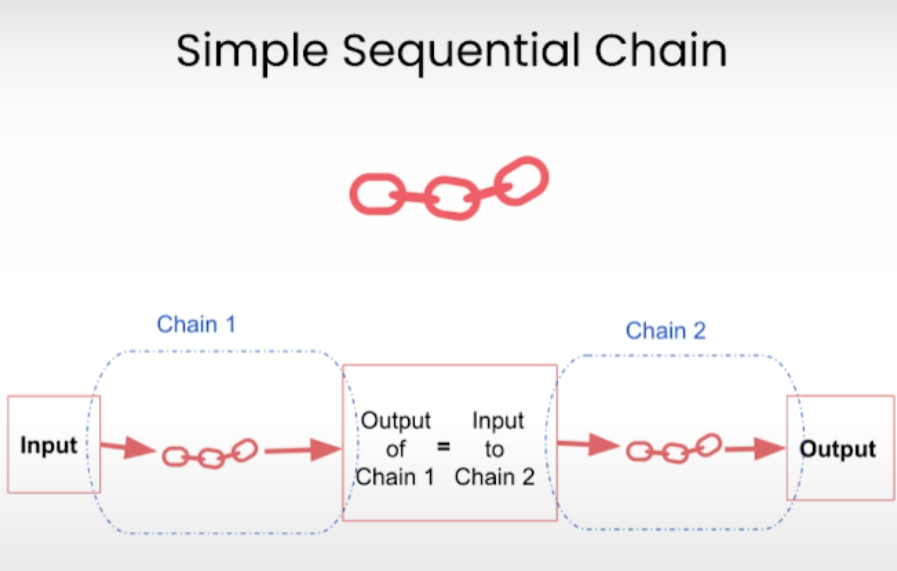



In the following example, we want to send a product to the LLM. The first LLM will be responsible for generating a creative name for a company that would produce this product, and then a second LLM will create a description for that company.

In the next cell, we present the traditional way of defining this chain using the `LLMChain` class. **This approach is now part of the classic LangChain API and is shown here mainly for compatibility with older materials.** After that, we’ll show how to implement the same logic using the newer Runnable-based approach, which is the preferred default for new code.

In [12]:
from langchain_classic.chains import LLMChain, SimpleSequentialChain

# prompt template 1
first_prompt = ChatPromptTemplate.from_template(
    "What is the best name to describe \n    a company that makes {product}? Return only one name.",
)

# Chain 1
chain_one = LLMChain(llm=llm, prompt=first_prompt)

# Chain 2
# prompt template 2
second_prompt = ChatPromptTemplate.from_template(
    "Write a 20 words description for the following \n    company:{company_name}"
)

chain_two = LLMChain(llm=llm, prompt=second_prompt)

overall_simple_chain = SimpleSequentialChain(
    chains=[chain_one, chain_two],
    verbose=True
)

overall_simple_chain.invoke(product)

/tmp/ipykernel_20299/1020833452.py:9: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use `RunnableSequence, e.g., `prompt | llm`` instead.
  chain_one = LLMChain(llm=llm, prompt=first_prompt)




> Entering new SimpleSequentialChain chain...
RoyalSheets
RoyalSheets stands out with premium printing services, ensuring quality, efficiency, and reliability for businesses seeking excellence in their operational requirements. (20 words)

> Finished chain.


{'input': 'Queen Size Sheet Set',
 'output': 'RoyalSheets stands out with premium printing services, ensuring quality, efficiency, and reliability for businesses seeking excellence in their operational requirements. (20 words)'}

Now, in the next cell, we’ll show how to build the same chain using the `Runnable` format, which has been adopted in the more recent versions of LangChain. First, we define the second chain, with the addition of using the default structured output parser `StrOutputParser`.

```
# Combine using RunnableMap
full_chain = (
    RunnableMap({"company_name": chain1})  # gets company_name from first_chain output
    | second_chain  # passes it to second_chain
)
```

In this line, we use `RunnableMap` to extract the output from the first step `(chain1)` and rename it to `company_name`, adapting the format to what the next step in the chain expects. This output is then automatically passed to `second_chain`, which takes the key `company_name` as input.

In [13]:
from langchain_core.runnables import RunnableMap

# Chain 2 = company name ➝ description
second_prompt = ChatPromptTemplate.from_template(
    "Write a 20 words description for the following \n    company:{company_name}"
)
parser = StrOutputParser()
second_chain = second_prompt | llm | parser

# Combine using RunnableMap
full_chain = (
    RunnableMap({"company_name": chain1})  # gets company_name from first_chain output
    | second_chain  # passes it to second_chain
)

# Run the whole chain
product = "Queen Size Sheet Set"
description = full_chain.invoke({"product": product})

print(description)

Queen's Slumber Co. crafts luxurious, eco‑friendly bedding, blending timeless elegance with restful sleep for every dreamer in your home today.


## 3.3 SequentialChain

**Compared with `SimpleSequentialChain`, `SequentialChain` can pass multiple named variables across steps, which makes the workflow more flexible.** This is useful when one branch of the pipeline depends on an intermediate result while another branch still uses the original input. We’ll take advantage of this functionality in the following example.

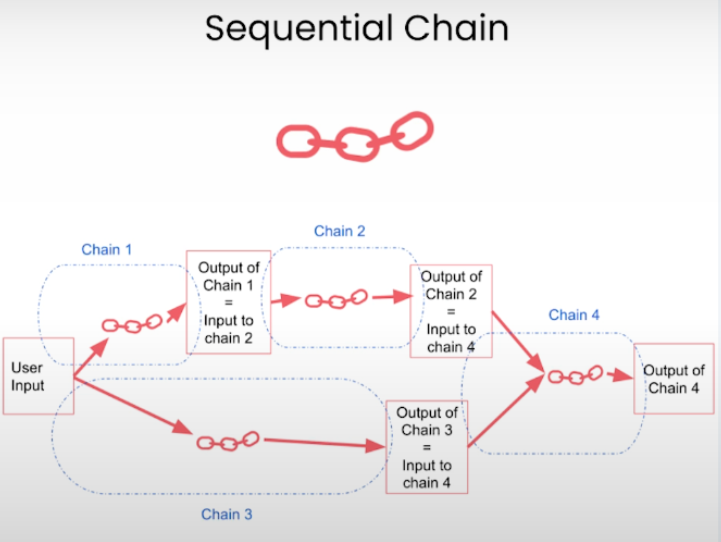

In the example in the following cells, we’ll build a sequential chain to process product reviews, performing multiple transformations on the original input `(Review)` in a chained manner.

The first step `(chain_one)` translates the original review into English. The output of this step is stored in the variable `English_Review`. Next, the second step `(chain_two)` uses this `English_Review` as input and generates a one-sentence summary, stored in the variable `summary`.

In parallel, the third step `(chain_three)` also directly receives the original text `(Review)` and identifies which language it was written in, returning this information in the variable language.

Finally, the fourth step `(chain_four)` uses the `summary` generated in the second step and the language identified in the third to produce a follow-up message in the same language as the original review. The final result is stored in the variable `followup_message`.

In [14]:
from langchain_classic.chains import LLMChain, SequentialChain

# prompt template 1: translate to english
first_prompt = ChatPromptTemplate.from_template(
    "Translate the following review to english:"
    "\n\n{Review}"
)
# chain 1: input= Review and output= English_Review
chain_one = LLMChain(llm=llm, prompt=first_prompt,
                     output_key="English_Review"
                    )

second_prompt = ChatPromptTemplate.from_template(
    "Can you summarize the following review in 1 sentence:"
    "\n\n{English_Review}"
)
# chain 2: input= English_Review and output= summary
chain_two = LLMChain(llm=llm, prompt=second_prompt,
                     output_key="summary"
                    )

# prompt template 3: detect language
third_prompt = ChatPromptTemplate.from_template(
    "What language is the following review:\n\n{Review}"
)
# chain 3: input= Review and output= language
chain_three = LLMChain(llm=llm, prompt=third_prompt,
                       output_key="language"
                      )


# prompt template 4: follow up message
fourth_prompt = ChatPromptTemplate.from_template(
    "Write a follow up response to the following "
    "summary in the specified language:"
    "\n\nSummary: {summary}\n\nLanguage: {language}"
)
# chain 4: input= summary, language and output= followup_message
chain_four = LLMChain(llm=llm, prompt=fourth_prompt,
                      output_key="followup_message"
                     )

# overall_chain: input= Review
# and output= English_Review, summary, followup_message
overall_chain = SequentialChain(
    chains=[chain_one, chain_two, chain_three, chain_four],
    input_variables=["Review"],
    output_variables=["English_Review", "summary", "followup_message"],
    verbose=True
)

review = df.Review[5]
overall_chain.invoke({"Review": review})



> Entering new SequentialChain chain...

> Finished chain.


{'Review': "Je trouve le goût médiocre. La mousse ne tient pas, c'est bizarre. J'achète les mêmes dans le commerce et le goût est bien meilleur...\nVieux lot ou contrefaçon !?",
 'English_Review': "I find the taste to be mediocre. The foam doesn't hold, it's strange. I buy the same at the store and the taste is much better... Is this an old batch or a counterfeit?",
 'summary': 'The reviewer finds theproduct’s taste mediocre and its foam unstable, suspects it may be an old or counterfeit batch because the same item from the store tastes far better.',
 'followup_message': 'Bonjour,\n\nMerci d’avoir pris le temps de partager votre expérience. Nous sommes désolés d’apprendre que le goût du produit vous a semblé médiocre et que la mousse était instable. Votre remarque concernant la possible différence d’âge ou d’authenticité du lot nous préoccupe particulièrement.\n\nAfin de résoudre ce problème au plus vite, pourriez‑vous nous indiquer le numéro de lot ou la date de péremption figurant su

Once again, let’s study how to develop the same chain, now using the Runnable-based system. **This is the style currently preferred in LangChain for new applications.** By looking at the next cell, we can already notice one trade-off: `SequentialChain` can look a bit more concise for teaching examples, while `Runnables` make the data flow more explicit and composable.

So far, the main new element in the code is the use of `RunnableLambda`, which allows us to insert custom logic directly into the chain flow in a flexible and controlled manner.

```
full_chain = (
    RunnableMap({
        "English_Review": lambda x: translate_chain.invoke({"Review": x["Review"]}),
        "language": lambda x: language_chain.invoke({"Review": x["Review"]}),
    })
```

In this code snippet, we use `RunnableMap` to perform two operations from the same input `(Review)`: one path translates the review into English, and the other detects the original language. The outputs are stored under the keys `English_Review` and `language`, respectively, so they can be reused in the next steps.

In [15]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableMap, RunnableLambda

# Model & parser
parser = StrOutputParser()

# === Prompt 1: Translate review to English ===
translate_prompt = ChatPromptTemplate.from_template(
    "Translate the following review to english:\n\n{Review}"
)
translate_chain = translate_prompt | llm | parser

# === Prompt 2: Summarize translated review ===
summary_prompt = ChatPromptTemplate.from_template(
    "Can you summarize the following review in 1 sentence:\n\n{English_Review}"
)
summary_chain = summary_prompt | llm | parser

# === Prompt 3: Detect original language ===
language_prompt = ChatPromptTemplate.from_template(
    "What language is the following review:\n\n{Review}"
)
language_chain = language_prompt | llm | parser

# === Prompt 4: Generate follow-up response ===
followup_prompt = ChatPromptTemplate.from_template(
    "Write a follow up response to the following summary in the specified language:"
    "\n\nSummary: {summary}\n\nLanguage: {language}"
)
followup_chain = followup_prompt | llm | parser

# === Full chain logic ===
full_chain = (
    RunnableMap({
        # Step 1: Translate to English
        "English_Review": lambda x: translate_chain.invoke({"Review": x["Review"]}), # 1
        # Step 2: Detect language
        "language": lambda x: language_chain.invoke({"Review": x["Review"]}), # 3
    })
    | RunnableLambda(lambda x: {
        **x,
        # Step 3: Summarize the English review
        "summary": summary_chain.invoke({"English_Review": x["English_Review"]}) # 2
    })
    | RunnableLambda(lambda x: {
        **x,
        # Step 4: Generate the follow-up message
        "followup_message": followup_chain.invoke({ # 4
            "summary": x["summary"],
            "language": x["language"]
        })
    })
)

# === Run the chain ===
review = df.Review[5]  # assume df is already defined
output = full_chain.invoke({"Review": review})

for key, value in output.items():
    print(f"{key}: {value}")


English_Review: I find the taste mediocre. The foam doesn’t hold, it’s weird. I buy the same thing in stores and the flavor is much better… Is it an old batch or a counterfeit?!
language: safe
summary: The reviewer found the product's taste to be mediocre and questioned its quality, suggesting it might be an old batch or counterfeit.
followup_message: **Follow-up Response (Safe Language):**  

Thank you for sharing your feedback regarding the product’s taste and quality concerns. We sincerely apologize that your experience did not meet your expectations. Our team is committed to ensuring consistent quality and freshness in every batch, and we take all customer concerns seriously.  

To help us investigate this matter, could you kindly provide the batch number or expiration date from the packaging? This will allow us to review our production and distribution processes thoroughly. Additionally, we’d be happy to assist with a replacement or refund—please contact our support team at [conta

# 4. Runnable Pipeline Example

Now let's look at another way to build a Runnable chain by mixing Python functions and LLM calls in the same sequence.

In this example, we will create a small pipeline in which:

1. a Python function creates a short campaign brief;
2. an LLM writes a first slogan draft;
3. another Python function defines a target length, between 0.5x and 1.5x the size of the original slogan;
4. a second LLM rewrites the slogan to match that target.

This gives us a example of the pattern:

**function → LLM → function → LLM**

Question: Can this Chain be considered an AI agent?

In [21]:
from random import uniform

from langchain_openrouter import ChatOpenRouter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

def build_brief(inputs: dict) -> dict:
    return {
        "product": inputs.get("product", "smart mug"),
        "audience": inputs.get("audience", "college students"),
        "tone": inputs.get("tone", "playful"),
    }


def compute_target_words(data: dict) -> int:
    original_words = max(1, len(data["draft_slogan"].split()))
    return max(3, round(original_words * uniform(0.5, 1.5)))


draft_prompt = ChatPromptTemplate.from_template("""
Write a short slogan for the product below.

Product: {product}
Audience: {audience}
Tone: {tone}

Return only the slogan.
""")


rewrite_prompt = ChatPromptTemplate.from_template("""
Rewrite the slogan below.

Original slogan: {draft_slogan}
Target length: about {target_words} words
Tone: {tone}

Return only the rewritten slogan.
""")


draft_chain = draft_prompt | llm | StrOutputParser()
target_length_chain = RunnableLambda(compute_target_words)
rewrite_chain = rewrite_prompt | llm | StrOutputParser()


pipeline = (
    RunnableLambda(build_brief)
    | {
        "product": lambda x: x["product"],
        "audience": lambda x: x["audience"],
        "tone": lambda x: x["tone"],
        "draft_slogan": draft_chain,
    }
    | {
        "product": lambda x: x["product"],
        "audience": lambda x: x["audience"],
        "tone": lambda x: x["tone"],
        "draft_slogan": lambda x: x["draft_slogan"],
        "target_words": target_length_chain,
    }
    | {
        "draft_slogan": lambda x: x["draft_slogan"],
        "target_words": lambda x: x["target_words"],
        "final_slogan": rewrite_chain,
    }
)

result = pipeline.invoke({
    "product": "smart mug",
    "audience": "college students",
    "tone": "playful",
})

print("Draft slogan:", result["draft_slogan"])
print("Target words:", result["target_words"])
print("Final slogan:", result["final_slogan"])

Draft slogan: Level up your study fuel. ☕️
Target words: 4
Final slogan: Boost your brain boost!
